<a href="https://colab.research.google.com/github/ChetanTiwari195/Aerchain_demo_project/blob/main/%22EDA_Optimising_NYC_Taxis_ChetanTiwari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings

In [ ]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sea.__version__)

numpy version: 2.4.4
pandas version: 3.0.2
matplotlib version: 3.10.9
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# for online

# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
# os.chdir('/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records') #when working online
data_dir = '/NewYorkTaxiEDA_DS_CT/trip_records'

if os.path.isdir(data_dir):
    os.chdir(data_dir)
else:
    raise FileNotFoundError(
        f"Directory not found: {data_dir}. "
        "Update the path to the folder containing the parquet files."
    )

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        data = pd.read_parquet(file_path)
        data['date'] = data['tpep_pickup_datetime'].dt.date
        data['hour'] = data['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in data['date'].unique():
            date_data = data[data['date'] == date]

            # Iterate through each hour of the selected date
            for hr in range(24):
                hr_data = date_data[date_data['hour'] == hr]

                if len(hr_data) > 0:
                # Sample 5% of the hourly data randomly
                  sample = hr_data.sample(frac = 0.05, random_state = 42)
                # add data of this hour to the dataframe
                  sampled_data = pd.concat([sampled_data,sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df,sampled_data]) # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet('eda_data')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file

pd.read_parquet('eda_data')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594944,2,2023-09-29 23:39:12,2023-09-29 23:55:07,5.0,3.32,1.0,N,249,48,1,...,0.5,4.68,0.0,1.0,28.08,2.5,NaN,2023-09-29,23,0.0
2595034,2,2023-09-29 23:19:08,2023-09-29 23:40:59,1.0,7.20,1.0,N,148,75,1,...,0.5,5.72,0.0,1.0,43.82,2.5,NaN,2023-09-29,23,0.0
2593663,1,2023-09-29 23:10:24,2023-09-29 23:17:47,1.0,1.30,1.0,N,45,79,2,...,0.5,0.00,0.0,1.0,14.30,2.5,NaN,2023-09-29,23,0.0
2593828,1,2023-09-29 23:38:48,2023-09-29 23:46:17,1.0,1.70,1.0,N,142,238,3,...,0.5,0.00,0.0,1.0,13.60,2.5,NaN,2023-09-29,23,0.0


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 1996062 entries, 428 to 2595923
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64      

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed

df = df.reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1996062 entries, 0 to 1996061
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

0    0.0
Name: airport_fee, dtype: float64
224576


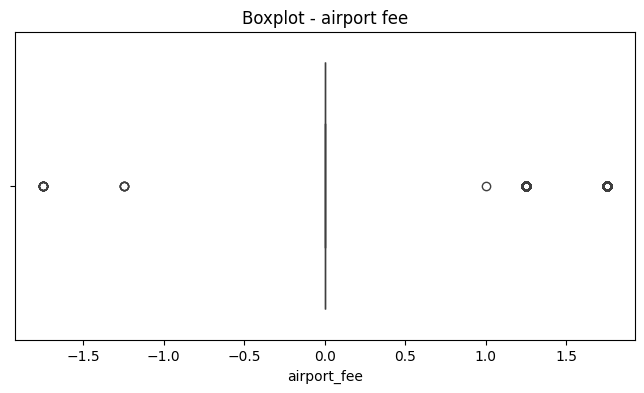

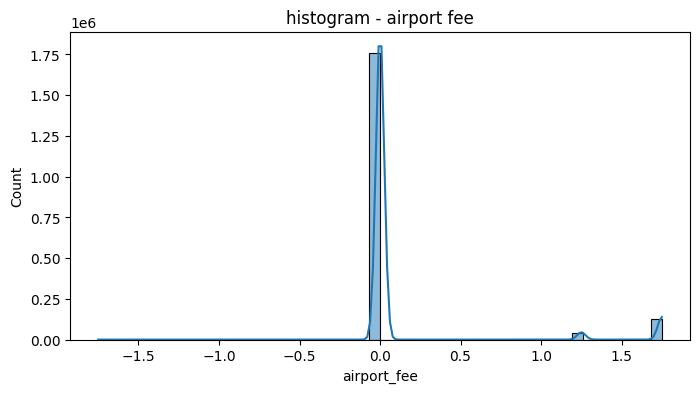

new: 0


In [ ]:
# Combine the two airport fee columns

df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

print(df['airport_fee'].mode())
print(df['Airport_fee'].isnull().sum())

plt.figure(figsize=(8, 4))
sea.boxplot(x=df['airport_fee'])
plt.title('Boxplot - airport fee')
plt.show()

plt.figure(figsize=(8, 4))
sea.histplot(df['airport_fee'], bins=50, kde=True)
plt.title('histogram - airport fee')
plt.show()

df['airport_fee'] = df['airport_fee'].fillna(df['airport_fee'].mode()[0])

print(f'new: {df['airport_fee'].isnull().sum()}')



In [ ]:
# dropping Airport_fee column
df = df.drop(columns=['Airport_fee'])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
print((df['fare_amount'] < 0).sum())

# no negative fare amount

0


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
print((df['RatecodeID'] < 0).sum())



0


In [ ]:
# Find which columns have negative values


num_cols = df.select_dtypes(include=['number']).columns

neg_summary = pd.DataFrame({
    'neg_count' : [(df[col] < 0).sum() for col in num_cols]
}, index=num_cols)

neg_summary


,neg_count
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,3
mta_tax,77


In [ ]:
# fix these negative values
neg_cols = neg_summary.index.tolist()

df = df[~(df[neg_cols] < 0).any(axis=1)]

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns

neg_summary = pd.DataFrame({
    'neg_count' : [(df[col] < 0).sum() for col in num_cols]
}, index=num_cols)

neg_summary

,neg_count
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,0
mta_tax,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column

missing_proportions = df.isna().mean()*100
missing_proportions.sort_values(ascending=False)

passenger_count          3.423483
store_and_fwd_flag       3.423483
congestion_surcharge     3.423483
RatecodeID               3.423483
VendorID                 0.000000
trip_distance            0.000000
tpep_dropoff_datetime    0.000000
tpep_pickup_datetime     0.000000
PULocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
DOLocationID             0.000000
mta_tax                  0.000000
tip_amount               0.000000
improvement_surcharge    0.000000
tolls_amount             0.000000
total_amount             0.000000
airport_fee              0.000000
date                     0.000000
hour                     0.000000
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

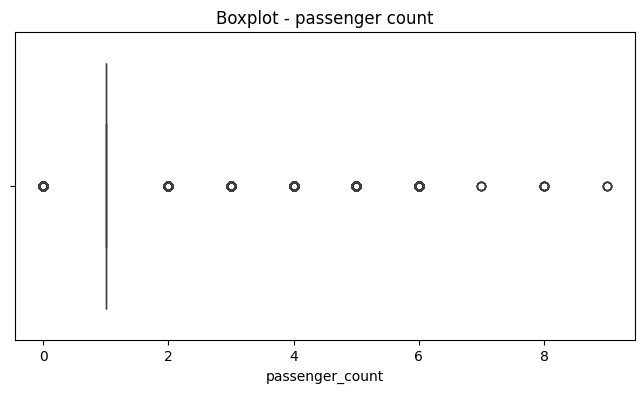

In [ ]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

# df[df.isna().any(axis=1)]
# df[df['passenger_count'].isna()]

plt.figure(figsize=(8, 4))
sea.boxplot(x=df['passenger_count'])
plt.title('Boxplot - passenger count')
plt.show()

df['passenger_count'].mode()

df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

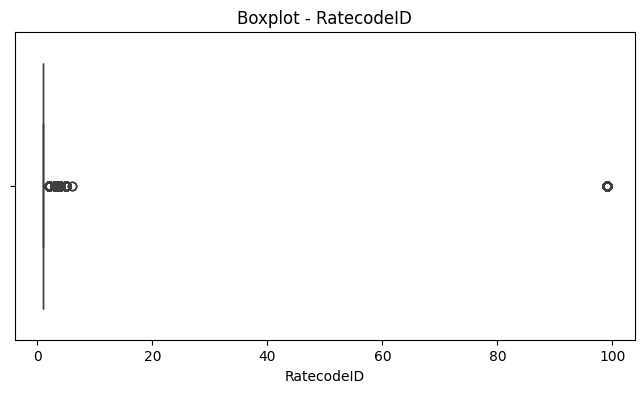

np.int64(0)

In [ ]:
# Fix missing values in 'RatecodeID'
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['RatecodeID'])
plt.title('Boxplot - RatecodeID')
plt.show()

# df[df['RatecodeID'].between(90,100)]

df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

df['RatecodeID'].isna().sum()

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
# plt.figure(figsize=(8, 4))
# sea.histplot(df['congestion_surcharge'], bins=50, kde=True)
# plt.title('histogram - congestion surcharge')
# plt.show()

# plt.figure(figsize=(8, 4))
# sea.boxplot(x=df['congestion_surcharge'])
# plt.title('Boxplot - congestion surcharge')
# plt.show()

df['congestion_surcharge'].mode()

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].mode()[0])
df['congestion_surcharge'].isna().sum()

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
# missing_proportions = df.isna().mean()*100
# missing_proportions.sort_values(ascending=False)

# plt.figure(figsize=(8, 4))
# sea.boxplot(x=df['store_and_fwd_flag'])
# plt.title('Boxplot - store and forward flag')
# plt.show()

(df['store_and_fwd_flag'] == 'N').mean() * 100

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')
df['store_and_fwd_flag'].isna().sum()

np.int64(0)

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1995979.0,1.733139,1.0,1.0,2.0,2.0,6.0,0.447634
tpep_pickup_datetime,1995979,2023-07-02 20:00:39.943826,2022-12-31 23:51:30,2023-04-02 16:10:25.500000,2023-06-27 15:46:36,2023-10-06 19:39:07.500000,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1995979,2023-07-02 20:18:06.232583,2022-12-31 23:56:06,2023-04-02 16:29:56,2023-06-27 16:03:28,2023-10-06 19:54:16,2024-01-01 20:50:55,NaN
passenger_count,1995979.0,1.356354,0.0,1.0,1.0,1.0,9.0,0.879531
trip_distance,1995979.0,3.854849,0.0,1.05,1.79,3.4,126360.46,127.334004
RatecodeID,1995979.0,1.611685,1.0,1.0,1.0,1.0,99.0,7.258146
PULocationID,1995979.0,165.288134,1.0,132.0,162.0,234.0,265.0,63.994409
DOLocationID,1995979.0,164.057286,1.0,114.0,162.0,234.0,265.0,69.801709
payment_type,1995979.0,1.163797,0.0,1.0,1.0,1.0,4.0,0.508197
fare_amount,1995979.0,19.919114,0.0,9.3,13.5,21.9,143163.45,102.95102


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

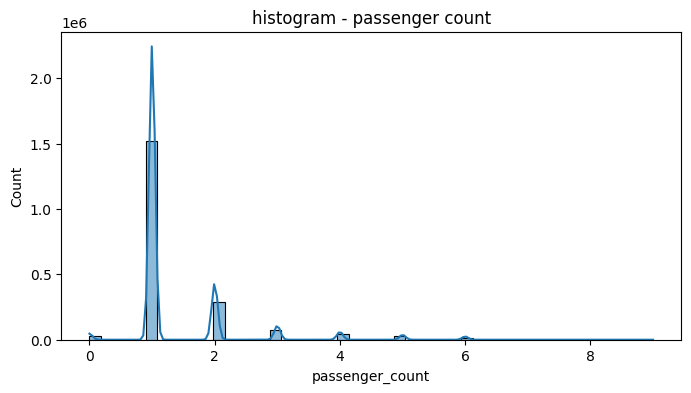

In [ ]:
# remove passenger_count > 6
plt.figure(figsize=(8, 4))
sea.histplot(df['passenger_count'], bins=50, kde=True)
plt.title('histogram - passenger count')
plt.show()

df = df[df['passenger_count'] <= 6]

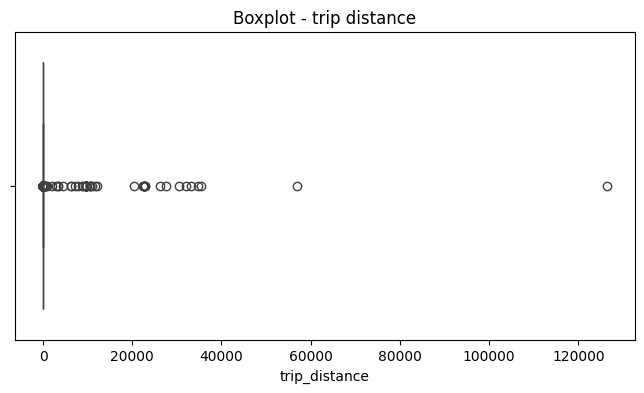

In [ ]:
# Continue with outlier handling
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['trip_distance'])
plt.title('Boxplot - trip distance')
plt.show()


In [ ]:
# trip distance
df = df[df['trip_distance'] <= 100]

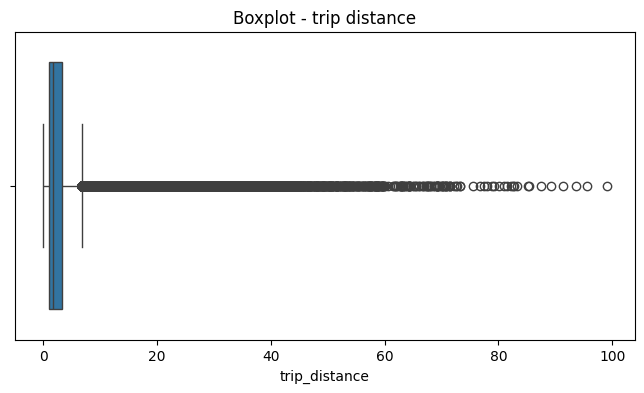

In [ ]:
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['trip_distance'])
plt.title('Boxplot - trip distance')
plt.show()

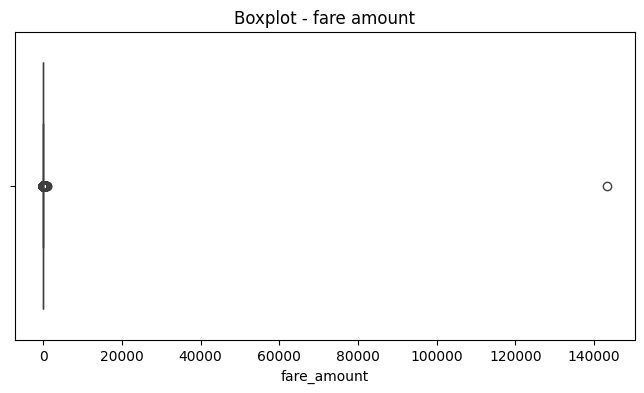

In [ ]:
# fare amount
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['fare_amount'])
plt.title('Boxplot - fare amount')
plt.show()

In [ ]:
df = df[df['fare_amount'] <= 350]

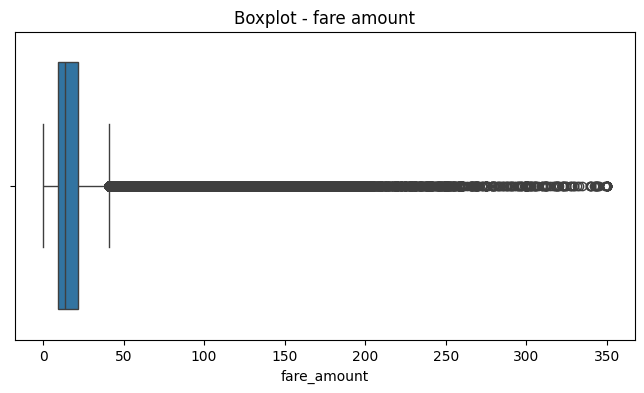

In [ ]:
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['fare_amount'])
plt.title('Boxplot - fare amount')
plt.show()

In [ ]:
df[(df['trip_distance'] == 0) & (df['fare_amount'] > 0) ].T

,77,118,127,236,280,299,305,306,353,369,...,1995783,1995788,1995802,1995813,1995910,1995919,1995928,1995961,1995964,1995972
VendorID,1,2,1,1,2,1,1,2,2,1,...,1,1,1,2,1,2,1,1,1,1
tpep_pickup_datetime,2023-01-01 00:37:09,2023-01-01 00:47:28,2023-01-01 00:45:06,2023-01-01 00:53:00,2023-01-01 01:34:06,2023-01-01 01:25:41,2023-01-01 01:26:38,2023-01-01 01:20:00,2023-01-01 01:45:25,2023-01-01 01:44:13,...,2023-09-28 23:23:54,2023-09-28 23:53:33,2023-09-29 01:32:09,2023-09-29 06:44:27,2023-09-29 14:52:44,2023-09-29 15:59:57,2023-09-29 15:34:45,2023-09-29 17:48:56,2023-09-29 17:47:45,2023-09-29 18:45:33
tpep_dropoff_datetime,2023-01-01 00:58:16,2023-01-01 00:47:32,2023-01-01 00:54:06,2023-01-01 01:07:31,2023-01-01 01:34:14,2023-01-01 01:25:45,2023-01-01 01:27:12,2023-01-01 01:20:02,2023-01-01 01:50:07,2023-01-01 01:44:30,...,2023-09-28 23:30:10,2023-09-29 00:01:43,2023-09-29 01:43:03,2023-09-29 06:44:53,2023-09-29 16:29:25,2023-09-29 17:44:59,2023-09-29 16:06:14,2023-09-29 18:00:05,2023-09-29 18:02:28,2023-09-29 19:07:42
passenger_count,1.0,0.0,1.0,0.0,2.0,0.0,1.0,4.0,3.0,1.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0
trip_distance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RatecodeID,1.0,5.0,1.0,1.0,5.0,1.0,5.0,5.0,1.0,5.0,...,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,N,N,N,N,N,N,N,N,N,Y,...,N,N,N,N,N,N,N,N,N,N
PULocationID,36,232,48,141,265,148,229,264,162,137,...,107,107,100,140,230,151,164,42,161,238
DOLocationID,7,232,48,79,265,148,229,264,162,137,...,79,113,141,140,88,132,138,75,144,186
payment_type,0,1,2,1,1,1,1,1,2,3,...,0,0,0,1,0,1,0,0,0,0


In [ ]:
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] > 0) )]

In [ ]:
df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['trip_distance'] > 0) ].T

""
VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type


In [ ]:
df[df['trip_distance'] > 100 ]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour


In [ ]:
df[(df['RatecodeID'] < 1) | (df['RatecodeID'] > 6) ].T

,669,1558,1823,2496,2772,2838,3985,4135,4168,4233,...,1994894,1994989,1994993,1995067,1995201,1995346,1995360,1995572,1995595,1995810
VendorID,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
tpep_pickup_datetime,2023-01-01 02:30:32,2023-01-01 11:39:40,2023-01-01 12:55:17,2023-01-01 15:35:00,2023-01-01 17:47:18,2023-01-01 17:45:54,2023-01-02 06:46:39,2023-01-02 08:05:22,2023-01-02 09:23:09,2023-01-02 09:50:55,...,2023-09-26 08:25:43,2023-09-26 14:04:18,2023-09-26 14:50:57,2023-09-26 18:57:05,2023-09-27 09:26:12,2023-09-27 18:03:48,2023-09-27 18:21:11,2023-09-28 13:21:36,2023-09-28 14:38:43,2023-09-29 05:42:59
tpep_dropoff_datetime,2023-01-01 03:05:47,2023-01-01 11:55:59,2023-01-01 13:17:08,2023-01-01 16:17:33,2023-01-01 18:12:13,2023-01-01 18:07:37,2023-01-02 06:57:35,2023-01-02 09:02:05,2023-01-02 09:38:34,2023-01-02 10:25:41,...,2023-09-26 09:07:59,2023-09-26 14:25:24,2023-09-26 15:56:44,2023-09-26 19:07:08,2023-09-27 11:02:38,2023-09-27 18:50:07,2023-09-27 19:50:14,2023-09-28 14:07:36,2023-09-28 15:06:57,2023-09-29 06:29:00
passenger_count,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
trip_distance,10.1,2.9,2.6,12.2,4.0,7.0,1.5,13.4,0.8,1.2,...,5.0,2.1,5.4,2.7,8.6,11.8,17.6,11.1,6.6,7.3
RatecodeID,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
store_and_fwd_flag,N,N,N,N,N,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
PULocationID,28,42,41,188,191,179,225,225,179,169,...,94,7,244,205,21,61,75,94,42,61
DOLocationID,86,47,167,203,218,121,17,212,7,69,...,166,223,163,218,14,55,222,107,182,142
payment_type,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


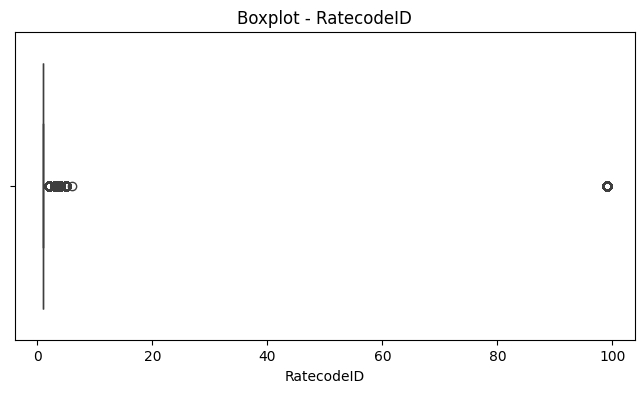

In [ ]:
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['RatecodeID'])
plt.title('Boxplot - RatecodeID')
plt.show()

In [ ]:
df = df[~((df['RatecodeID'] < 1) | (df['RatecodeID'] > 6))]

In [ ]:
df[(df['payment_type'] < 1) | (df['payment_type'] > 6) ].T

,4,15,42,43,46,52,69,104,125,129,...,1995817,1995857,1995870,1995881,1995882,1995935,1995959,1995962,1996006,1996011
VendorID,2,2,2,2,2,2,1,2,2,2,...,2,2,2,2,2,2,2,1,2,2
tpep_pickup_datetime,2023-01-01 00:43:00,2023-01-01 00:41:50,2023-01-01 00:37:21,2023-01-01 00:44:03,2023-01-01 00:50:55,2023-01-01 00:55:00,2023-01-01 00:28:22,2023-01-01 00:58:50,2023-01-01 00:16:00,2023-01-01 00:17:00,...,2023-09-29 06:40:00,2023-09-29 10:57:42,2023-09-29 11:49:58,2023-09-29 11:48:13,2023-09-29 12:43:06,2023-09-29 16:45:45,2023-09-29 17:03:20,2023-09-29 17:25:12,2023-09-29 19:16:04,2023-09-29 20:29:00
tpep_dropoff_datetime,2023-01-01 01:01:00,2023-01-01 01:14:50,2023-01-01 00:54:18,2023-01-01 01:13:49,2023-01-01 01:19:06,2023-01-01 01:07:00,2023-01-01 00:41:25,2023-01-01 01:17:07,2023-01-01 00:38:00,2023-01-01 00:46:00,...,2023-09-29 07:02:31,2023-09-29 11:23:04,2023-09-29 12:28:54,2023-09-29 12:13:59,2023-09-29 13:04:16,2023-09-29 17:42:47,2023-09-29 18:19:18,2023-09-29 17:41:17,2023-09-29 19:40:35,2023-09-29 21:41:00
passenger_count,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
trip_distance,19.24,10.77,4.52,9.19,2.74,1.89,2.9,4.43,4.77,5.89,...,10.63,2.6,4.09,2.09,8.06,11.43,15.47,2.3,3.98,14.09
RatecodeID,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,N,N,N,N,N,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
PULocationID,66,151,114,239,90,141,263,33,90,144,...,79,65,239,158,263,166,41,141,107,188
DOLocationID,107,106,262,256,48,143,137,68,262,262,...,138,87,234,79,138,73,10,239,43,142
payment_type,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


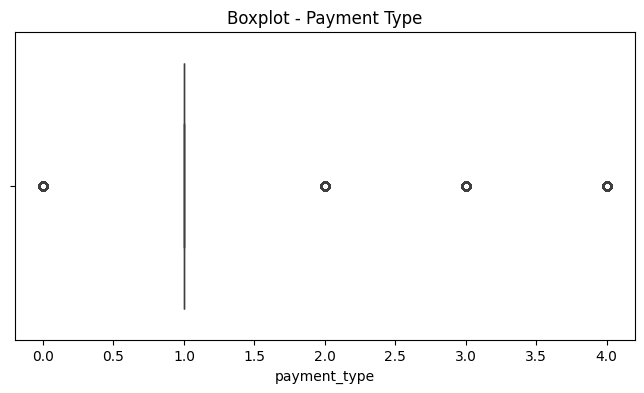

In [ ]:
plt.figure(figsize=(8, 4))
sea.boxplot(x=df['payment_type'])
plt.title('Boxplot - Payment Type')
plt.show()

In [ ]:
df = df[~((df['payment_type'] < 1) | (df['payment_type'] > 6))]

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1893860.0,1.741646,1.0,1.0,2.0,2.0,2.0,0.43773
tpep_pickup_datetime,1893860,2023-07-01 19:12:51.279409,2022-12-31 23:51:30,2023-04-01 19:31:28,2023-06-25 22:18:12,2023-10-05 18:58:52.500000,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1893860,2023-07-01 19:30:11.493625,2022-12-31 23:56:06,2023-04-01 19:47:24.750000,2023-06-25 22:35:29,2023-10-05 19:16:38.500000,2024-01-01 20:50:55,NaN
passenger_count,1893860.0,1.371749,0.0,1.0,1.0,1.0,6.0,0.894608
trip_distance,1893860.0,3.465829,0.0,1.08,1.8,3.39,99.02,4.511156
RatecodeID,1893860.0,1.062446,1.0,1.0,1.0,1.0,6.0,0.332008
PULocationID,1893860.0,165.689784,1.0,132.0,162.0,234.0,265.0,63.474465
DOLocationID,1893860.0,164.484767,1.0,114.0,162.0,234.0,265.0,69.643676
payment_type,1893860.0,1.200581,1.0,1.0,1.0,1.0,4.0,0.457422
fare_amount,1893860.0,19.552329,0.0,9.3,13.5,21.9,350.0,17.704804


In [ ]:
# Do any columns need standardising?

# data is pretty clesn now for data analysis and visualization , and there is no further need of standardising

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'date',
 'hour']

df[(df['trip_distance'] == 0) & (df['fare_amount'] > 0)]
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical (datetime)
* `tpep_dropoff_datetime`: Numerical (datetime)
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical
 

The following monetary parameters belong in the same category, is it categorical or numerical?
 Ans: Numerical

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hr_trend = df.groupby('pickup_hour').size()
hr_trend

pickup_hour
0      53071
1      35510
2      23304
3      15126
4       9374
5       9864
6      24691
7      50201
8      70151
9      80428
10     88000
11     95618
12    103871
13    107375
14    115338
15    118241
16    118200
17    128207
18    134378
19    120735
20    107712
21    107454
22     99191
23     77820
dtype: int64

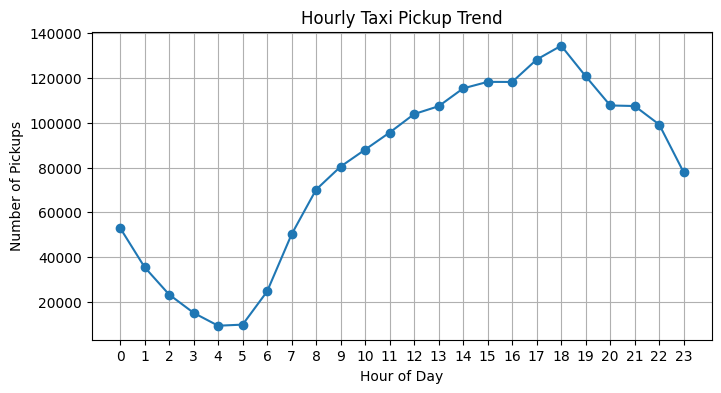

In [ ]:

plt.figure(figsize=(8,4))
plt.plot(hr_trend.index, hr_trend.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.title('Hourly Taxi Pickup Trend')
plt.xticks(range(24))
plt.grid()
plt.show()

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
day_trend = df.groupby('pickup_day').size().sort_values(ascending=False)
day_trend


pickup_day
Thursday     297116
Wednesday    291041
Friday       280495
Saturday     275945
Tuesday      274709
Sunday       238643
Monday       235911
dtype: int64

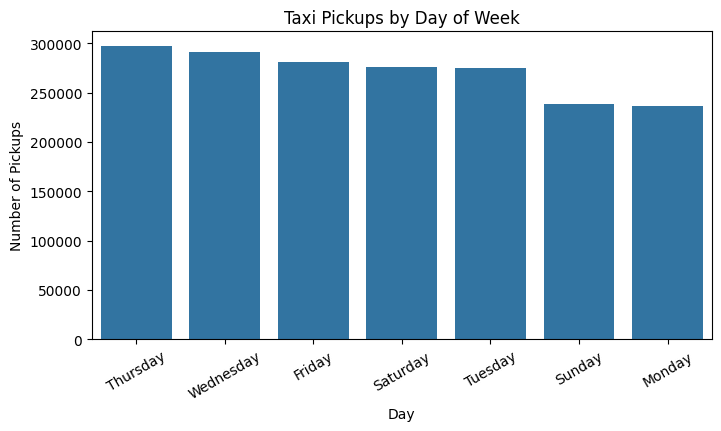

In [ ]:
plt.figure(figsize=(8,4))
sea.barplot(x=day_trend.index, y=day_trend.values)
plt.title('Taxi Pickups by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
month_trend = df.groupby('pickup_month').size()
month_trend


pickup_month
April        164155
August       139474
December     162917
February     145619
January      153726
July         144375
June         164619
March        169843
May          174879
November     163832
October      172193
September    138228
dtype: int64

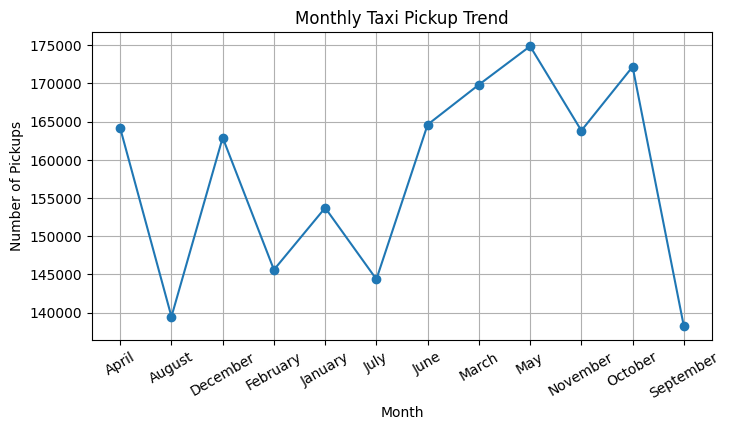

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(month_trend.index, month_trend.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Taxi Pickup Trend')
plt.xticks(rotation=30)
plt.grid()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

zero_count = (df[cols] == 0).sum()
zero_count


fare_amount         558
tip_amount       406905
total_amount        292
trip_distance       298
dtype: int64

In [ ]:

neg_count = (df[cols] < 0).sum()
neg_count

fare_amount      0
tip_amount       0
total_amount     0
trip_distance    0
dtype: int64

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?
</br>
<b>Ans:</b> i think we can remove 'fare_amount', 'total_amount', 'trip_distance' as thes can be cancelled rides, logging errors or faulty records, but 'tip_amount' can be zero as many passengers do not tip the drivers, so it would be best to create a copy where there is no 0 values for fare_amount', 'total_amount', 'trip_distance' records

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
df_no_zero = df.copy()

In [ ]:
df_no_zero[df_no_zero['trip_distance'] == 0][['trip_distance', 'fare_amount', 'total_amount']].describe()

,trip_distance,fare_amount,total_amount
count,298.0,298.0,298.000000
mean,0.0,0.0,1.097550
std,0.0,0.0,6.396331
min,0.0,0.0,0.000000
25%,0.0,0.0,0.000000
50%,0.0,0.0,0.000000
75%,0.0,0.0,0.000000
max,0.0,0.0,100.250000


In [ ]:
df_no_zero = df_no_zero[~(
    (df_no_zero['trip_distance'] == 0) &
    (df_no_zero['fare_amount'] == 0) &
    (df_no_zero['total_amount'] == 0)
)]

In [ ]:
df_no_zero[df_no_zero[cols] == 0].count()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                73
RatecodeID                    0
store_and_fwd_flag            0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                 333
extra                         0
mta_tax                       0
tip_amount               406680
tolls_amount                  0
improvement_surcharge         0
total_amount                 67
congestion_surcharge          0
airport_fee                   0
date                          0
hour                          0
pickup_hour                   0
pickup_day                    0
pickup_month                  0
dtype: int64

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

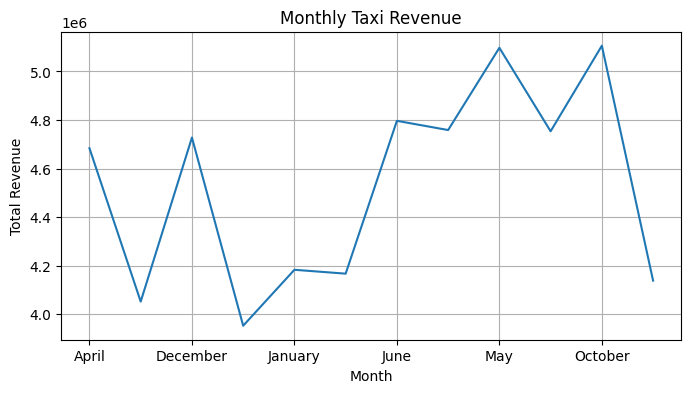

pickup_month
October      5105967.78
May          5097389.49
June         4796596.53
March        4758672.64
November     4753587.31
December     4727750.26
April        4683805.23
January      4183139.50
July         4167141.39
September    4138477.53
August       4052140.13
February     3952735.96
Name: total_amount, dtype: float64

In [ ]:
# Group data by month and analyse monthly revenue
df.groupby('pickup_month')['total_amount'].sum().plot(kind='line', figsize=(8,4))
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue') 
plt.title('Monthly Taxi Revenue')
plt.grid()
plt.show()

df.groupby('pickup_month')['total_amount'].sum().sort_values(ascending=False)


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
quarterly_proportion


pickup_quarter
1    23.695633
2    26.788840
3    22.709204
4    26.806324
Name: total_amount, dtype: float64

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [ ]:
# Show how trip fare is affected by distance
df_no_zero[df_no_zero['trip_distance'] == 0][['trip_distance', 'fare_amount', 'total_amount']].describe()


,trip_distance,fare_amount,total_amount
count,73.0,73.0,73.000000
mean,0.0,0.0,4.480411
std,0.0,0.0,12.385444
min,0.0,0.0,0.010000
25%,0.0,0.0,1.000000
50%,0.0,0.0,2.250000
75%,0.0,0.0,4.000000
max,0.0,0.0,100.250000


In [ ]:
df_no_zero = df_no_zero[~((df_no_zero['trip_distance'] > 0) & (df_no_zero['fare_amount'] == 0))]

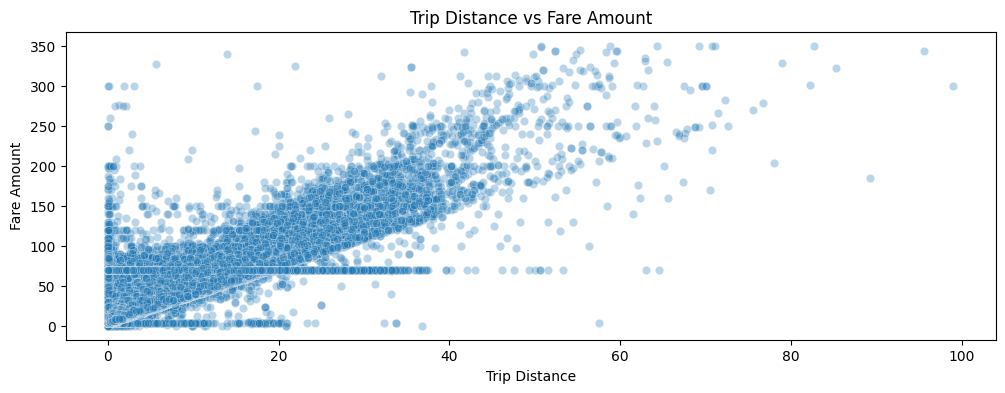

In [ ]:
plt.figure(figsize=(12,4))
sea.scatterplot(x=df_no_zero['trip_distance'], y=df_no_zero['fare_amount'], alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
df = df[~(df['trip_duration'] < 0)]

In [ ]:
df_no_zero['trip_duration'] = (df_no_zero['tpep_dropoff_datetime'] - df_no_zero['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
df_no_zero = df_no_zero[~(df_no_zero['trip_duration'] < 0)]

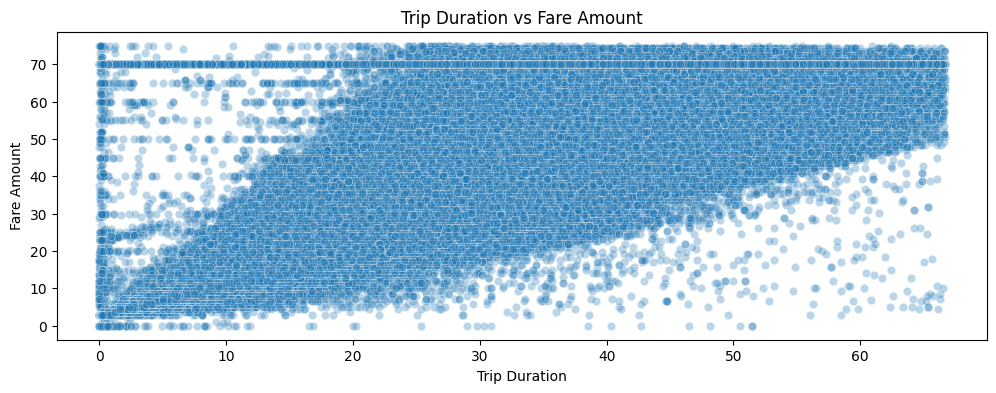

In [ ]:
# Show relationship between fare and trip duration
df_plot = df_no_zero[(df_no_zero['fare_amount']  < df_no_zero['fare_amount'].quantile(0.99)) & (df_no_zero['trip_duration'] < df_no_zero['trip_duration'].quantile(0.99))]

plt.figure(figsize=(12,4))
sea.scatterplot(y=df_plot['fare_amount'], x=df_plot['trip_duration'], alpha=0.3)
plt.xlabel('Trip Duration')
plt.ylabel('Fare Amount')
plt.title('Trip Duration vs Fare Amount')
plt.show()




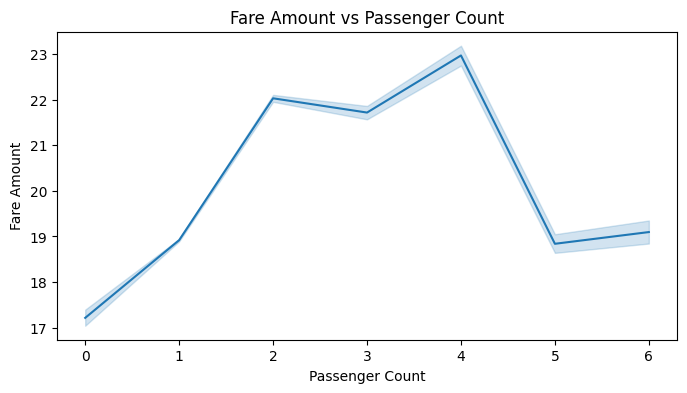

In [ ]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(8,4))
sea.lineplot(x='passenger_count', y='fare_amount', data=df_no_zero)
plt.title('Fare Amount vs Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()




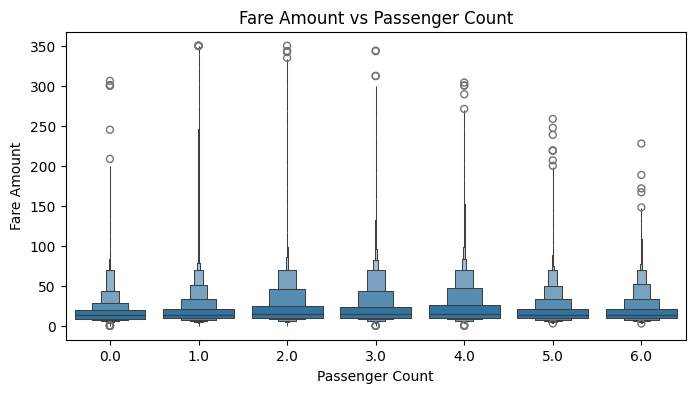

In [ ]:
plt.figure(figsize=(8,4))
sea.boxenplot(x='passenger_count', y='fare_amount', data=df_no_zero)
plt.title('Fare Amount vs Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()

In [ ]:
# Show relationship between tip and trip distance

df_plot = df_no_zero[
    (df_no_zero['trip_distance'] > 0) &
    (df_no_zero['trip_distance'] < df_no_zero['trip_distance'].quantile(0.99)) &
    (df_no_zero['tip_amount'] < df_no_zero['tip_amount'].quantile(0.99))
]

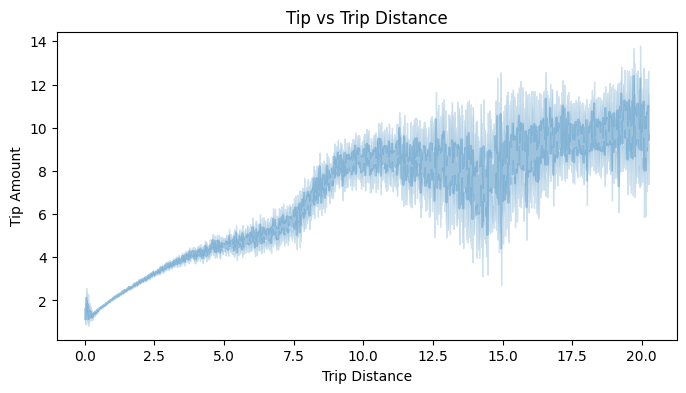

In [ ]:
plt.figure(figsize=(8,4))
sea.lineplot(x='trip_distance', y='tip_amount', data=df_plot, alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip vs Trip Distance')
plt.show()

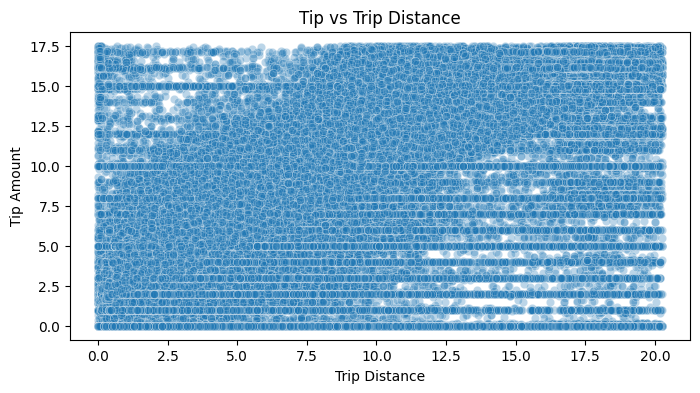

In [ ]:
plt.figure(figsize=(8,4))
sea.scatterplot(x='trip_distance', y='tip_amount', data=df_plot, alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip vs Trip Distance')
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
# Analyse the distribution of different payment types (payment_type).

payment_counts = df['payment_type'].value_counts()
payment_counts


payment_type
1    1547230
2     326325
4      13013
3       7250
Name: count, dtype: int64

In [ ]:
payment_counts = df['payment_type'].value_counts(normalize=True) * 100
payment_counts

payment_type
1    81.698981
2    17.231064
4     0.687130
3     0.382825
Name: proportion, dtype: float64

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/NewYorkTaxiEDA_DS_CT/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    str     
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    str     
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 18.5 KB
None


<Axes: >

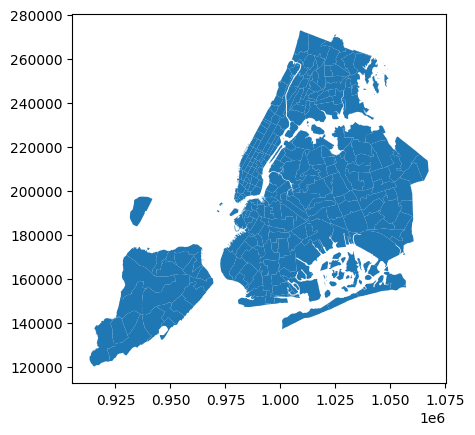

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID

df_merged = df_no_zero.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

In [ ]:
df_merged.T

,0,1,2,3,4,5,6,7,8,9,...,1893378,1893379,1893380,1893381,1893382,1893383,1893384,1893385,1893386,1893387
VendorID,2,2,2,2,1,2,2,2,1,2,...,1,2,2,2,2,2,2,1,1,2
tpep_pickup_datetime,2023-01-01 00:07:18,2023-01-01 00:16:41,2023-01-01 00:14:03,2023-01-01 00:24:30,2023-01-01 00:42:56,2023-01-01 00:58:00,2023-01-01 00:16:06,2023-01-01 00:44:09,2023-01-01 00:15:25,2023-01-01 00:14:47,...,2023-09-29 23:33:20,2023-09-29 23:16:04,2023-09-29 23:53:38,2023-09-29 23:35:20,2023-09-29 23:57:02,2023-09-29 23:39:12,2023-09-29 23:19:08,2023-09-29 23:10:24,2023-09-29 23:38:48,2023-09-29 23:41:15
tpep_dropoff_datetime,2023-01-01 00:23:15,2023-01-01 00:21:46,2023-01-01 00:24:36,2023-01-01 00:29:55,2023-01-01 01:16:33,2023-01-01 01:08:31,2023-01-01 00:31:59,2023-01-01 01:01:17,2023-01-01 00:22:35,2023-01-01 00:20:18,...,2023-09-29 23:59:44,2023-09-29 23:22:58,2023-09-30 00:00:27,2023-09-29 23:42:28,2023-09-30 00:14:50,2023-09-29 23:55:07,2023-09-29 23:40:59,2023-09-29 23:17:47,2023-09-29 23:46:17,2023-09-29 23:47:08
passenger_count,1.0,2.0,3.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,...,1.0,1.0,2.0,3.0,1.0,5.0,1.0,1.0,1.0,1.0
trip_distance,7.74,1.24,1.44,0.54,7.1,1.59,3.16,7.64,0.9,0.78,...,9.3,0.98,1.5,0.84,10.19,3.32,7.2,1.3,1.7,1.27
RatecodeID,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,N,N,N,N,N,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
PULocationID,138,161,237,143,246,79,79,132,148,237,...,237,211,142,79,138,249,148,45,142,239
DOLocationID,256,237,141,142,37,164,256,95,114,229,...,95,148,68,79,263,48,75,79,238,236
payment_type,2,1,2,2,1,1,1,1,1,2,...,1,1,2,1,1,1,1,2,3,1


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trip_by_location = df_merged.groupby('LocationID').size()
trip_by_location


LocationID
1.0         49
2.0          2
4.0       1874
6.0         23
7.0        724
         ...  
259.0        3
260.0      290
261.0     9980
262.0    24697
263.0    36418
Length: 248, dtype: int64

In [ ]:
df_merged.groupby('zone').size()


zone
Alphabet City               1874
Arrochar/Fort Wadsworth       23
Astoria                      724
Astoria Park                   5
Auburndale                     6
                           ...  
Woodlawn/Wakefield             3
Woodside                     290
World Trade Center          9980
Yorkville East             24697
Yorkville West             36418
Length: 248, dtype: int64

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame

trip_by_location = df_merged.groupby('LocationID').size().rename('trip_count')
df_merged = zones.merge(trip_by_location, left_on='LocationID', right_index=True, how='left')
df_merged = df_merged.rename(columns={0: 'trip_count'})
df_merged.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",49.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1874.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

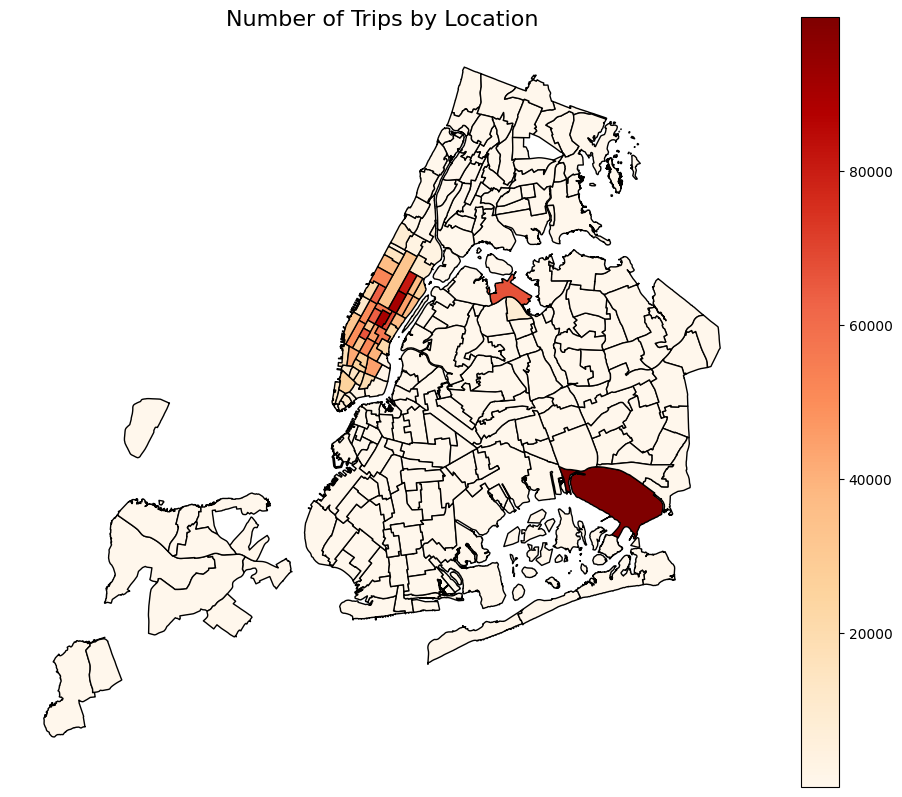

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
df_merged.plot(column='trip_count', ax=ax, legend=True, cmap='OrRd', edgecolor='black')
ax.set_title('Number of Trips by Location', fontsize=16)
ax.set_axis_off()
plt.show()


In [ ]:
# can you try displaying the zones DF sorted by the number of trips?

zones_sorted = df_merged.sort_values(by='trip_count', ascending=False)
zones_sorted

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",99986.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",90967.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",89812.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",81151.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",68678.0
...,...,...,...,...,...,...,...,...
109,110,0.103946,0.000526,Great Kills Park,110,Staten Island,"POLYGON ((951420.092 139894.411, 951856.209 13...",NaN
175,176,0.151995,0.000658,Oakwood,176,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148...",NaN
213,214,0.135300,0.000812,South Beach/Dongan Hills,214,Staten Island,"POLYGON ((960669.201 156319.132, 960902.551 15...",NaN
220,221,0.166218,0.000890,Stapleton,221,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",NaN


In [ ]:
df_merged['trip_count'] = df_merged['trip_count'].fillna(0)

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

df_no_zero['speed'] = df_no_zero['trip_distance'] / (df_no_zero['trip_duration'] / 60)


In [ ]:
df_no_zero['speed']

0          29.115987
1          14.636066
2           8.189573
3           5.981538
5          12.672286
             ...    
1996057    12.515183
1996058    19.771167
1996059    10.564334
1996060    13.630290
1996061    12.951841
Name: speed, Length: 1893333, dtype: float64

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = df_no_zero.groupby('pickup_hour').size().sort_values()
hourly_trips

pickup_hour
4       9368
5       9861
3      15120
2      23295
6      24687
1      35460
7      50184
0      53060
8      70129
23     77807
9      80401
10     87980
11     95591
22     99182
12    103834
13    107337
21    107432
20    107690
14    115296
16    118168
15    118209
19    120707
17    128182
18    134353
dtype: int64

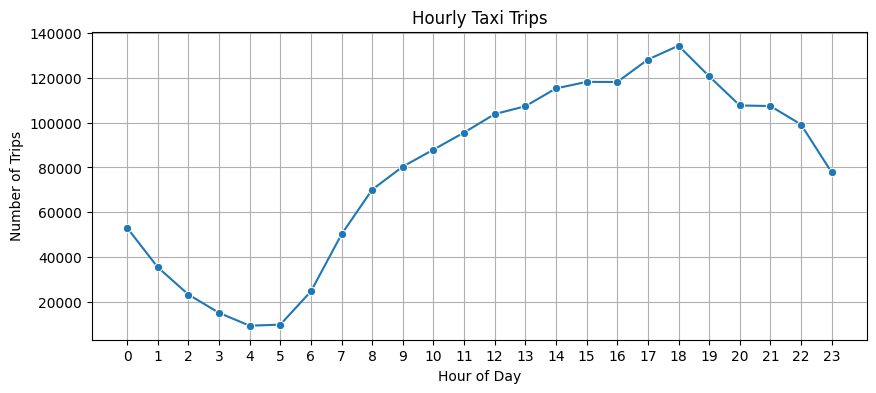

In [ ]:
plt.figure(figsize=(10,4))
sea.lineplot(x=hourly_trips.index, y=hourly_trips.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Taxi Trips')
plt.xticks(range(24))
plt.grid()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05
scaled_hourly_trips = hourly_trips / sample_fraction
scaled_hourly_trips

pickup_hour
4      187360.0
5      197220.0
3      302400.0
2      465900.0
6      493740.0
1      709200.0
7     1003680.0
0     1061200.0
8     1402580.0
23    1556140.0
9     1608020.0
10    1759600.0
11    1911820.0
22    1983640.0
12    2076680.0
13    2146740.0
21    2148640.0
20    2153800.0
14    2305920.0
16    2363360.0
15    2364180.0
19    2414140.0
17    2563640.0
18    2687060.0
dtype: float64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends
day_trend = df_no_zero.groupby('pickup_day').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
day_trend



pickup_day
Monday       235832
Tuesday      274628
Wednesday    290971
Thursday     297035
Friday       280424
Saturday     275904
Sunday       238539
dtype: int64

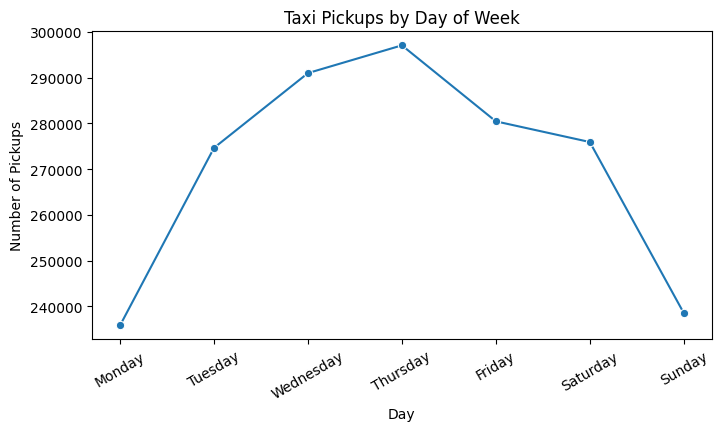

In [ ]:
plt.figure(figsize=(8,4))
sea.lineplot(x=day_trend.index, y=day_trend.values, marker='o')
plt.title('Taxi Pickups by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=30)
plt.show()

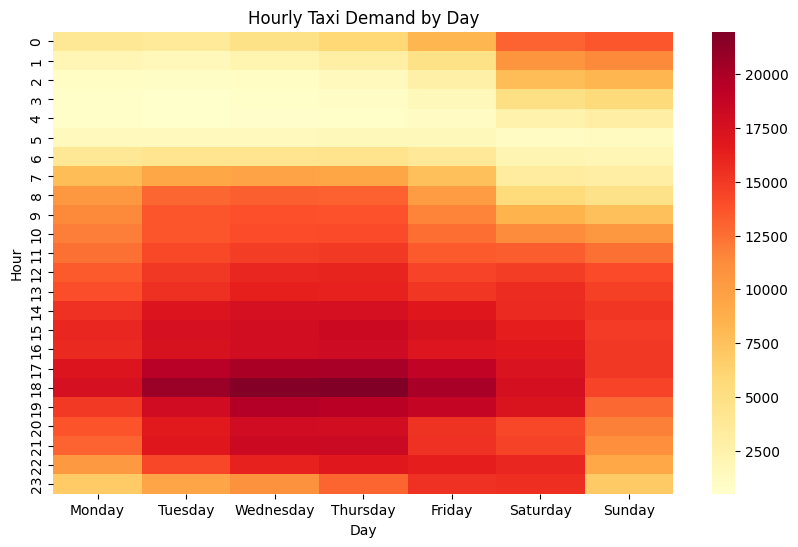

In [ ]:
pivot = df_no_zero.pivot_table(
    index='pickup_hour',
    columns='pickup_day',
    aggfunc='size'
)

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot[order]

plt.figure(figsize=(10,6))
sea.heatmap(pivot, cmap='YlOrRd')
plt.title('Hourly Taxi Demand by Day')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# top drop off zones
# merge zones with dropoff location id
df_merged = df_no_zero.merge(zones, left_on='DOLocationID', right_on='LocationID', how='left')

# merging dropoff trip count to merged df
trip_by_location_dropoff = df_merged.groupby('LocationID').size().rename('trip_count_dropoff')
df_merged = zones.merge(trip_by_location_dropoff, left_on='LocationID', right_index=True, how='left')
df_merged = df_merged.rename(columns={0: 'trip_count_dropoff'})

# mergerging pickup trip count to merged df
df_merged = df_merged.merge(trip_by_location, left_on='LocationID', right_index=True, how='left')
df_merged['trip_count'] = df_merged['trip_count'].fillna(0)
df_merged.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count_dropoff,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",5433.0,49.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",3.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",117.0,0.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",7147.0,1874.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",9.0,0.0


In [ ]:
# top pickup_zones
top_pickup_zones = df_merged.sort_values(by='trip_count', ascending=False)[['zone', 'trip_count']].head(10)
top_pickup_zones

,zone,trip_count
131,JFK Airport,99986.0
236,Upper East Side South,90967.0
160,Midtown Center,89812.0
235,Upper East Side North,81151.0
161,Midtown East,68678.0
137,LaGuardia Airport,67030.0
185,Penn Station/Madison Sq West,66253.0
229,Times Sq/Theatre District,63914.0
141,Lincoln Square East,63667.0
169,Murray Hill,56822.0


In [ ]:
# top drop_off_zones
top_dropoff_zones = df_merged.sort_values(by='trip_count_dropoff', ascending=False)[['zone', 'trip_count_dropoff']].head(10)
top_dropoff_zones

,zone,trip_count_dropoff
235,Upper East Side North,85055.0
236,Upper East Side South,81144.0
160,Midtown Center,74858.0
229,Times Sq/Theatre District,58799.0
169,Murray Hill,56600.0
161,Midtown East,54468.0
141,Lincoln Square East,53801.0
238,Upper West Side South,53578.0
140,Lenox Hill West,50698.0
67,East Chelsea,48274.0


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
df_merged['pickup_dropoff_ratio'] = df_merged['trip_count'] / (df_merged['trip_count_dropoff'] + 1)
pickup_dropoff_ratio = df_merged[['zone', 'pickup_dropoff_ratio']].sort_values(by='pickup_dropoff_ratio', ascending=False)
top_10_ratio = pickup_dropoff_ratio.head(10)
bottom_10_ratio = pickup_dropoff_ratio.tail(10)


In [ ]:
top_10_ratio

,zone,pickup_dropoff_ratio
69,East Elmhurst,9.585284
131,JFK Airport,4.894317
137,LaGuardia Airport,2.925158
185,Penn Station/Madison Sq West,1.582199
113,Greenwich Village South,1.381176
42,Central Park,1.375971
248,West Village,1.328380
161,Midtown East,1.260864
160,Midtown Center,1.199749
99,Garment District,1.197477


In [ ]:
bottom_10_ratio

,zone,pickup_dropoff_ratio
175,Oakwood,0.0
213,South Beach/Dongan Hills,0.0
220,Stapleton,0.0
29,Broad Channel,0.0
244,West Brighton,0.0
102,Governor's Island/Ellis Island/Liberty Island,NaN
103,Governor's Island/Ellis Island/Liberty Island,NaN
104,Governor's Island/Ellis Island/Liberty Island,NaN
109,Great Kills Park,NaN
198,Rikers Island,NaN


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df_no_zero[(df_no_zero['pickup_hour'] >= 23) | (df_no_zero['pickup_hour'] <= 5)]

# pickup zones during night hours
top_pickup_night = night_df.groupby('PULocationID').size().sort_values(ascending=False).reset_index(name='trip_count')
top_pickup_night = top_pickup_night.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

# dropoff zones during night hours
top_dropoff_night = night_df.groupby('DOLocationID').size().sort_values(ascending=False).reset_index(name='trip_count')
top_dropoff_night = top_dropoff_night.merge(zones, left_on='DOLocationID', right_on='LocationID', how='left')


In [ ]:
top_pickup_night

,PULocationID,trip_count,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,79,16248,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
1,132,15081,132.0,0.245479,0.002038,JFK Airport,132.0,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
2,249,13066,249.0,0.036384,0.000072,West Village,249.0,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."
3,48,10879,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21..."
4,148,10081,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20..."
...,...,...,...,...,...,...,...,...,...
204,205,1,205.0,0.141953,0.000766,Saint Albans,205.0,Queens,"POLYGON ((1049028.76 195325.647, 1049096.735 1..."
205,242,1,242.0,0.138136,0.000360,Van Nest/Morris Park,242.0,Bronx,"POLYGON ((1029641.165 248417.271, 1029604.462 ..."
206,235,1,235.0,0.076167,0.000213,University Heights/Morris Heights,235.0,Bronx,"POLYGON ((1009288.916 253270.48, 1009240.677 2..."
207,248,1,248.0,0.056919,0.000150,West Farms/Bronx River,248.0,Bronx,"POLYGON ((1021898.26 245357.487, 1022005.186 2..."


In [ ]:
top_dropoff_night

,DOLocationID,trip_count,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,79,8669,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
1,48,7122,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21..."
2,170,6539,170.0,0.045769,0.000074,Murray Hill,170.0,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21..."
3,68,6021,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."
4,107,5978,107.0,0.038041,0.000075,Gramercy,107.0,Manhattan,"POLYGON ((989131.643 205749.904, 989084.531 20..."
...,...,...,...,...,...,...,...,...,...
253,30,3,30.0,0.094510,0.000146,Broad Channel,30.0,Queens,"POLYGON ((1034013.272 163473.152, 1034866.459 ..."
254,5,2,5.0,0.092146,0.000498,Arden Heights,5.0,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
255,176,2,176.0,0.151995,0.000658,Oakwood,176.0,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148..."
256,59,1,59.0,0.037795,0.000063,Crotona Park,59.0,Bronx,"POLYGON ((1014848.343 245121.005, 1015049.583 ..."


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
night_revenue = night_df.groupby('pickup_hour')['total_amount'].sum()
night_revenue


pickup_hour
0     1547212.14
1      942543.66
2      585395.17
3      397723.14
4      309726.29
5      378841.69
23    2380153.23
Name: total_amount, dtype: float64

In [ ]:
day_df = df_no_zero[(df_no_zero['pickup_hour'] >= 6) & (df_no_zero['pickup_hour'] <= 22)]
day_revenue = day_df.groupby('pickup_hour')['total_amount'].sum() 
day_revenue

pickup_hour
6      784457.45
7     1370114.17
8     1852077.83
9     2156212.87
10    2373509.94
11    2602856.06
12    2883911.67
13    3076083.22
14    3448126.93
15    3512437.26
16    3750544.97
17    3845874.92
18    3812882.39
19    3426045.04
20    3038489.83
21    3044788.07
22    2894757.36
Name: total_amount, dtype: float64

##### Pricing Strategy

In [ ]:
df_no_zero.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'date',
 'hour',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'trip_duration',
 'speed']

In [ ]:
# night revenue as a proportion of total revenue by day

night_prop = ((night_df.groupby('pickup_day')['total_amount'].sum()) / ((night_df.groupby('pickup_day')['total_amount'].sum()).sum()))*100
night_prop

pickup_day
Friday       15.476351
Monday        9.254353
Saturday     22.381672
Sunday       21.200577
Thursday     12.230565
Tuesday       9.123809
Wednesday    10.332674
Name: total_amount, dtype: float64

In [ ]:
day_prop = ((day_df.groupby('pickup_day')['total_amount'].sum()) / ((day_df.groupby('pickup_day')['total_amount'].sum()).sum()))*100
day_prop

pickup_day
Friday       14.709172
Monday       13.409362
Saturday     12.410313
Sunday       11.804578
Thursday     16.374982
Tuesday      15.223306
Wednesday    16.068288
Name: total_amount, dtype: float64

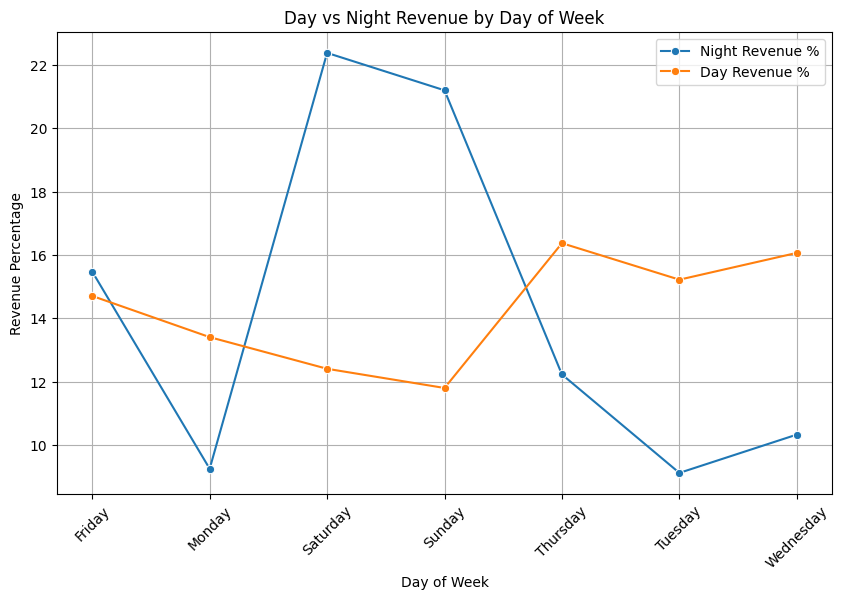

In [ ]:
# plot a stacked lineplot to show the day and night revenue trends across the hours of the day
plt.figure(figsize=(10,6))
sea.lineplot(x=night_prop.index, y=night_prop.values, marker='o', label='Night Revenue %')
sea.lineplot(x=day_prop.index, y=day_prop.values, marker='o', label='Day Revenue %')
plt.xlabel('Day of Week') 
plt.ylabel('Revenue Percentage')
plt.title('Day vs Night Revenue by Day of Week')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts
# (df_no_zero['passenger_count']  <= 0).sum()

# for calculation creating a new df with only entries having passenger count and trip_distance > 0
df_fare_per_mile = df_no_zero[(df_no_zero['passenger_count'] > 0) & (df_no_zero['trip_distance'] > 0)]

In [ ]:
df_fare_per_mile['fare_per_mile_per_passenger'] = df_fare_per_mile['fare_amount'] / (df_fare_per_mile['trip_distance'] * df_fare_per_mile['passenger_count'])

In [ ]:
df_fare_per_mile.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()

passenger_count
1.0    10.943459
2.0     6.477272
3.0     3.944883
4.0     4.280118
5.0     1.703928
6.0     1.351611
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
# for days
df_fare_per_mile.groupby('pickup_day')['fare_per_mile_per_passenger'].mean()


pickup_day
Friday        9.348813
Monday        9.523261
Saturday      8.888826
Sunday       10.245585
Thursday      9.790426
Tuesday       9.813526
Wednesday     9.848247
Name: fare_per_mile_per_passenger, dtype: float64

In [ ]:
# for hours
df_fare_per_mile.groupby('pickup_hour')['fare_per_mile_per_passenger'].mean()

pickup_hour
0      8.674311
1      9.071931
2      8.580030
3      9.355106
4     13.073781
5     12.559718
6      9.724764
7      8.875759
8      9.281275
9      9.018392
10     9.139489
11     9.326693
12    10.164929
13    10.398088
14     9.841491
15    10.883507
16    11.670965
17    10.308821
18     9.963045
19     9.876559
20     8.181879
21     7.973465
22     8.610092
23     8.900613
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors
df_fare_per_mile.groupby('VendorID')['fare_per_mile_per_passenger'].mean()


VendorID
1     7.063895
2    10.468018
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers

def distance_tier(distance):
    if distance <=2:
        return '0-2 miles'
    elif distance <= 5:
        return '2-5 miles'
    else:
        return '5+ miles'
    
df_fare_per_mile['distance_tier'] = df_fare_per_mile['trip_distance'].apply(distance_tier)

In [ ]:
df_fare_per_mile.groupby(['distance_tier', 'VendorID'])['fare_per_mile_per_passenger'].mean().unstack()

VendorID,1,2
distance_tier,,
0-2 miles,8.597551,15.094187
2-5 miles,5.517042,5.620031
5+ miles,3.815460,3.764975


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# to normalise tip amount by fare amount to get tip percentage, so that we not get biased decisions based on distance or counts etc

df_tip = df_fare_per_mile[df_fare_per_mile['fare_amount'] > 0].copy()


In [ ]:
df_tip['tip_percentage'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100

# removing outliers for better analysis of tip percentage
df_tip = df_tip[df_tip['tip_percentage'] < df_tip['tip_percentage'].quantile(0.99)]

In [ ]:
# tip and distance
df_tip.groupby('distance_tier')['tip_percentage'].mean()

distance_tier
0-2 miles    21.614991
2-5 miles    18.690789
5+ miles     16.673650
Name: tip_percentage, dtype: float64

In [ ]:
# tip and passenger count
df_tip.groupby('passenger_count')['tip_percentage'].mean()

passenger_count
1.0    20.249631
2.0    19.284666
3.0    18.535895
4.0    16.924909
5.0    20.036113
6.0    20.066249
Name: tip_percentage, dtype: float64

In [ ]:
# tip and pickup time
df_tip.groupby('pickup_hour')['tip_percentage'].mean()

pickup_hour
0     19.857917
1     19.900331
2     19.780334
3     18.882928
4     17.289143
5     17.502866
6     18.173513
7     19.442201
8     19.818323
9     19.500484
10    19.040223
11    18.906834
12    18.868498
13    18.727420
14    18.701808
15    18.669791
16    20.285744
17    21.024648
18    21.589317
19    21.550587
20    20.993063
21    21.088905
22    20.798831
23    20.166517
Name: tip_percentage, dtype: float64

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days
passenger_hr_count = df_no_zero.groupby('pickup_hour')['passenger_count'].mean()
passenger_day_count = df_no_zero.groupby('pickup_day')['passenger_count'].mean()



In [ ]:
passenger_hr_count

pickup_hour
0     1.417904
1     1.421094
2     1.436832
3     1.441204
4     1.404675
5     1.292465
6     1.246810
7     1.260820
8     1.278629
9     1.302807
10    1.340111
11    1.352178
12    1.369397
13    1.369341
14    1.376509
15    1.394716
16    1.390723
17    1.377830
18    1.363259
19    1.376474
20    1.385876
21    1.413657
22    1.419955
23    1.413138
Name: passenger_count, dtype: float64

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
passenger_day_count

pickup_day
Friday       1.386846
Monday       1.348184
Saturday     1.464669
Sunday       1.449235
Thursday     1.330183
Tuesday      1.320262
Wednesday    1.316210
Name: passenger_count, dtype: float64

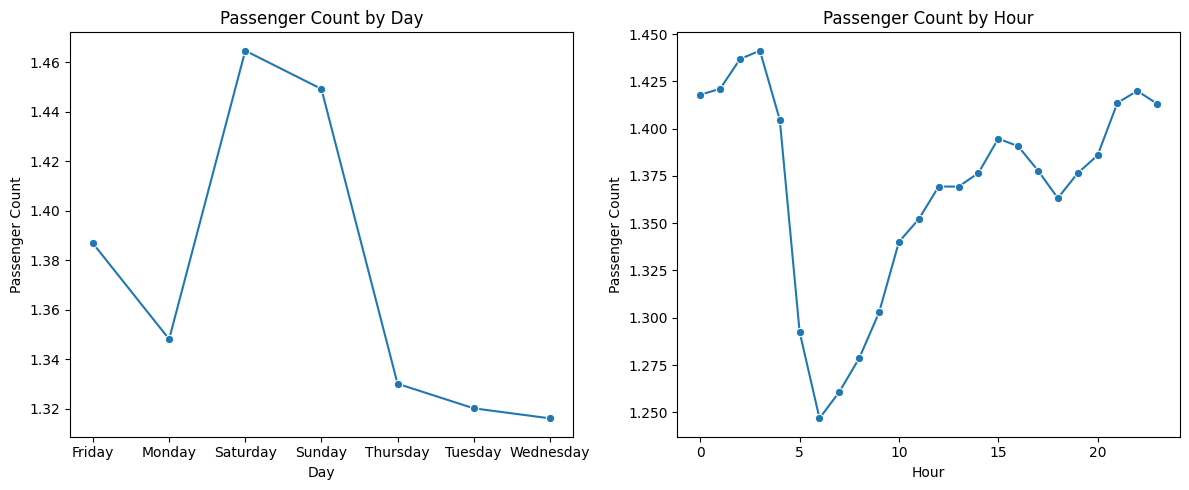

In [ ]:
# plot a line graph for passenger_day_count and passenger_hr_count
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sea.lineplot(x=passenger_day_count.index, y=passenger_day_count.values, marker='o')
plt.title('Passenger Count by Day')
plt.xlabel('Day')
plt.ylabel('Passenger Count')

plt.subplot(1, 2, 2)
sea.lineplot(x=passenger_hr_count.index, y=passenger_hr_count.values, marker='o')
plt.title('Passenger Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()


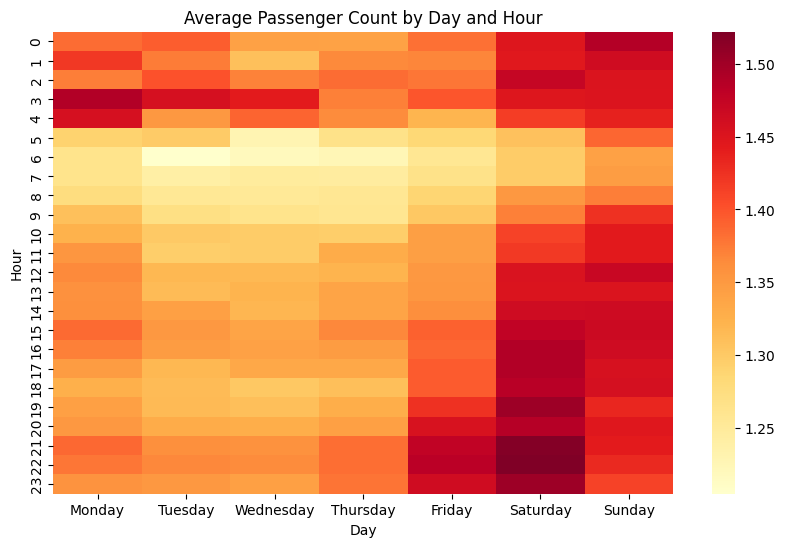

In [ ]:
# want a heat map for passenger count by day and hour
pivot_passenger = df_no_zero.pivot_table(
    index='pickup_hour',
    columns='pickup_day',
    values='passenger_count',
    aggfunc='mean'
)
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_passenger = pivot_passenger[order]
plt.figure(figsize=(10,6))
sea.heatmap(pivot_passenger, cmap='YlOrRd')
plt.title('Average Passenger Count by Day and Hour')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.show()


In [ ]:
# How does passenger count vary across zones
passenger_by_location = df_no_zero.groupby('PULocationID')['passenger_count'].mean().rename('avg_passenger_count')
df_merged = df_merged.merge(passenger_by_location, left_on='LocationID', right_index=True, how='left')
df_merged['avg_passenger_count'] = df_merged['avg_passenger_count'].fillna(0)
df_merged.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count_dropoff,trip_count,pickup_dropoff_ratio,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",5433.0,49.0,0.009017,1.285714
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",3.0,2.0,0.500000,1.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",117.0,0.0,0.000000,0.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",7147.0,1874.0,0.262171,1.423693
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",9.0,0.0,0.000000,0.000000


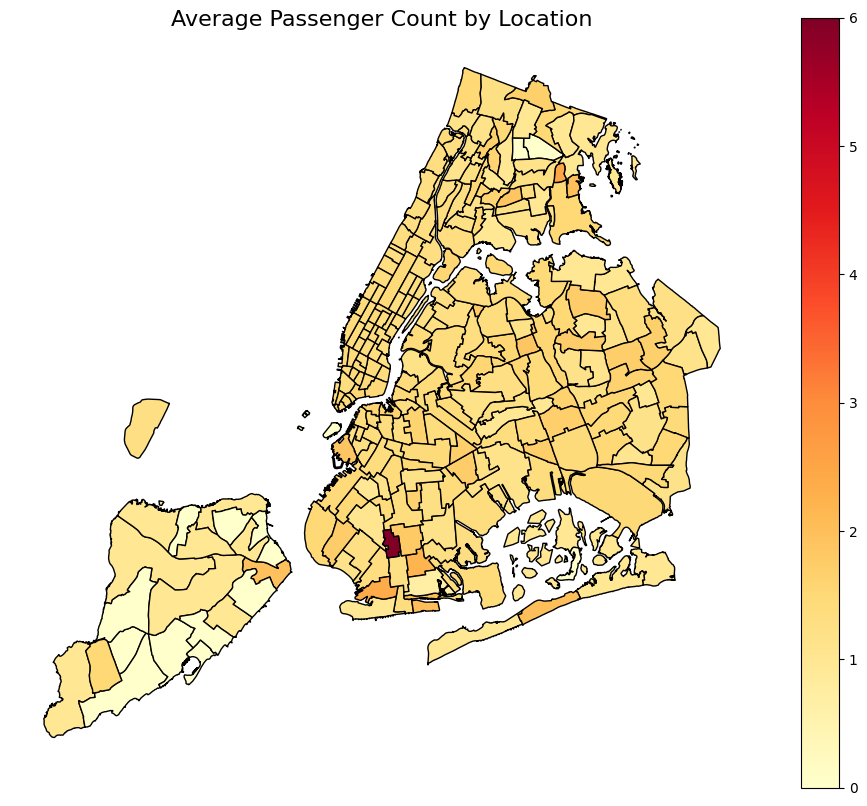

In [ ]:
# choropleth map to show the average passenger count across zones
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df_merged.plot(column='avg_passenger_count', ax=ax, legend=True, cmap='YlOrRd', edgecolor='black')
ax.set_title('Average Passenger Count by Location', fontsize=16)
ax.set_axis_off()
plt.show()

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?

df_no_zero['surcharge_count'] = df_no_zero[['congestion_surcharge', 'airport_fee']].gt(0).sum(axis=1)
surcharge_counts = df_no_zero['surcharge_count'].value_counts()
surcharge_counts


surcharge_count
1    1746830
2      94398
0      52105
Name: count, dtype: int64

In [ ]:
df_no_zero[df_no_zero['congestion_surcharge'] > 0].groupby('pickup_hour').size()

pickup_hour
0      48422
1      33098
2      22143
3      14290
4       8569
5       8367
6      21601
7      46131
8      65735
9      75551
10     82753
11     90532
12     98129
13    100977
14    107687
15    110188
16    110098
17    120489
18    126849
19    113352
20    100630
21    100473
22     92086
23     70329
dtype: int64

In [ ]:
# surcharge according to zones
surcharge_by_location = df_no_zero.groupby('PULocationID')['surcharge_count'].mean().rename('avg_surcharge_count')

df_merged['avg_surcharge_count'] = df_merged['LocationID'].map(surcharge_by_location).fillna(0)
df_merged['avg_surcharge_count'] = df_merged['avg_surcharge_count'].fillna(0)
df_merged.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count_dropoff,trip_count,pickup_dropoff_ratio,avg_passenger_count,avg_surcharge_count_x,avg_surcharge_count_y,avg_surcharge_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",5433.0,49.0,0.009017,1.285714,0.020408,0.020408,0.020408
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",3.0,2.0,0.500000,1.000000,1.000000,1.000000,1.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",117.0,0.0,0.000000,0.000000,0.000000,NaN,0.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",7147.0,1874.0,0.262171,1.423693,0.997332,0.997332,0.997332
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",9.0,0.0,0.000000,0.000000,0.000000,NaN,0.000000


In [ ]:
df_merged[df_merged['avg_surcharge_count'] > 0].groupby('zone')['avg_surcharge_count'].mean().sort_values(ascending=False)

zone
LaGuardia Airport          1.628196
JFK Airport                1.434991
East Elmhurst              1.310886
City Island                1.000000
Crotona Park               1.000000
                             ...   
Bellerose                  0.071429
Crown Heights North        0.064516
Arrochar/Fort Wadsworth    0.043478
Howard Beach               0.032258
Newark Airport             0.020408
Name: avg_surcharge_count, Length: 201, dtype: float64

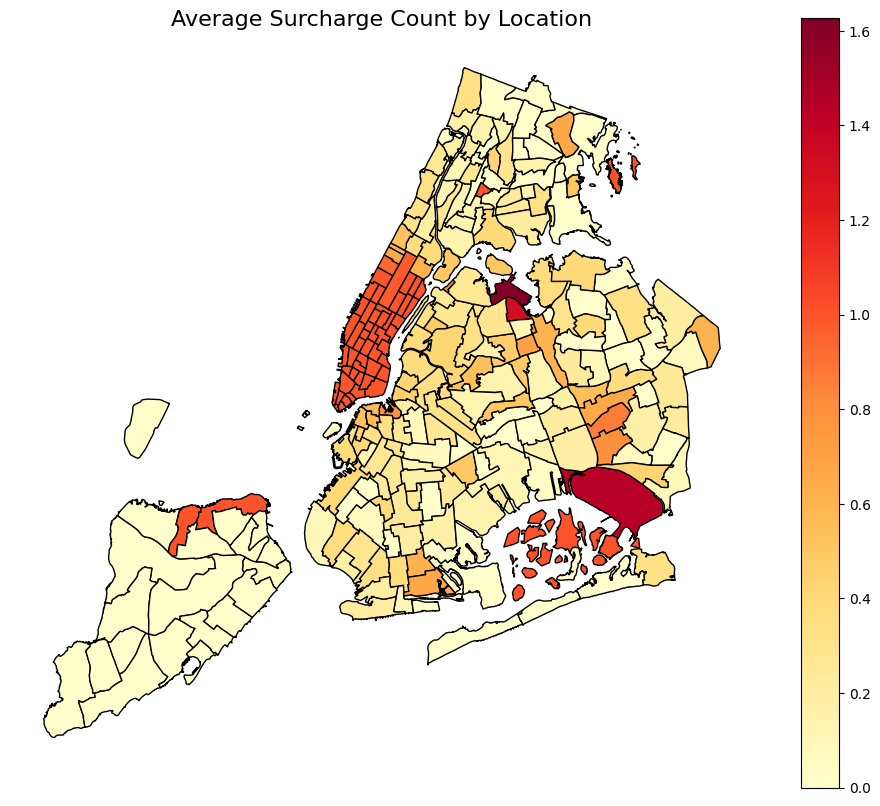

In [ ]:
# choropleth map to show the average surcharge count across zones
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df_merged.plot(column='avg_surcharge_count', ax=ax, legend=True, cmap='YlOrRd', edgecolor='black')
ax.set_title('Average Surcharge Count by Location', fontsize=16)
ax.set_axis_off()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

we can clearly see from the analysis that afternoon and evening times are busy compared to early morning hours, and mostly people took taxis in middle of the week comapred to weekends, and mostly people take taxis in certain regions more than others, like Queens and Manhattan, so to optimize the routing and dispatching we need to focus on peak hours, so we need to allocate drivers to locations like queens and manhattan which have more demand compared to other regions, we can predict next location based on the trends amd patterns of pickup and drop offs in differnet regions.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

as we can clearly see from the trend that most taxis people take are from weekdays, so we can conclude that mostly these people are office goers, so we can place more taxis in residential areas in the morning and in office areas in the evening, we can place taxis at different hotspots like commercial areas, airports etc for more effeciency.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

we can increase prices in rush hours, and in high demand areas to manage the demand and supply gap, and we can also provide discounts in non rush hours to increase the demand in those hours. we can set zone based pricing by increasing the rates for high demand areas and lowering the prices for non rush areas.